---
## 🎯 Step 5 — K-Means Clustering

**How K-Means works:** Randomly places K centroids, assigns each point to the nearest centroid, moves centroids to the mean of their points, repeats until stable.

**Hyperparameter to tune:** Number of clusters K → we use the **Elbow Method** and **Silhouette Score** to find the best K.

Best K by Silhouette: 2


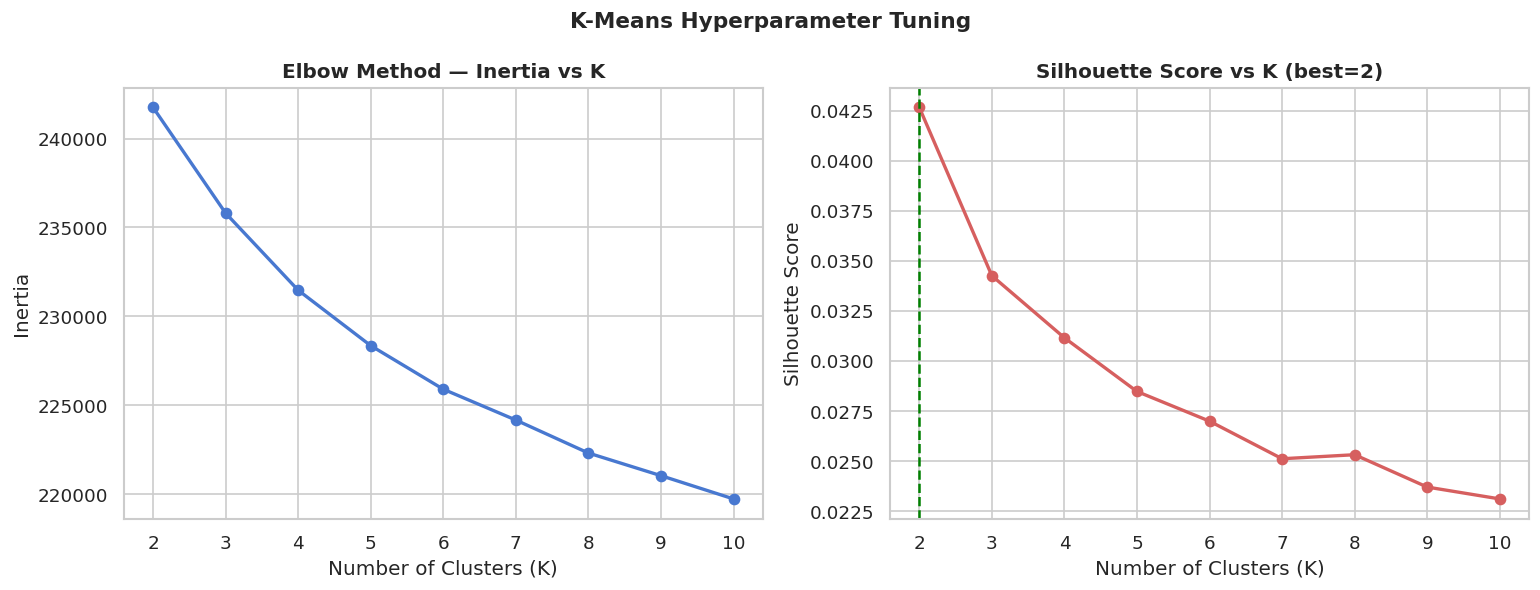

In [ ]:
# Hyperparameter tuning: find best K
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=6)
axes[0].set_title('Elbow Method — Inertia vs K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=6)
axes[1].axvline(best_k, color='green', linestyle='--', linewidth=1.5)
axes[1].set_title(f'Silhouette Score vs K (best K={best_k})', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('K-Means Hyperparameter Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Best K by Silhouette: {best_k}")

In [ ]:
# Train final K-Means with best K
km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
km_labels = km_final.fit_predict(X_pca)

# Metrics
km_sil = silhouette_score(X_pca, km_labels)
km_dbi = davies_bouldin_score(X_pca, km_labels)
km_chi = calinski_harabasz_score(X_pca, km_labels)
km_ari = adjusted_rand_score(y_all, km_labels)
km_nmi = normalized_mutual_info_score(y_all, km_labels)

print("=== K-Means Results ===")
print(f"Silhouette Score    : {km_sil:.4f}  (higher = better, max=1)")
print(f"Davies-Bouldin Index: {km_dbi:.4f}  (lower = better)")
print(f"Calinski-Harabasz  : {km_chi:.2f} (higher = better)")
print(f"Adjusted Rand Index : {km_ari:.4f}  (vs ground truth)")
print(f"Norm. Mutual Info  : {km_nmi:.4f}  (vs ground truth)")

=== K-Means Results ===
Silhouette Score    : 0.0427  (higher = better, max=1)
Davies-Bouldin Index: 4.6027  (lower = better)
Calinski-Harabasz  : 121.45 (higher = better)
Adjusted Rand Index : 0.0293  (vs ground truth)
Norm. Mutual Info  : 0.0215  (vs ground truth)


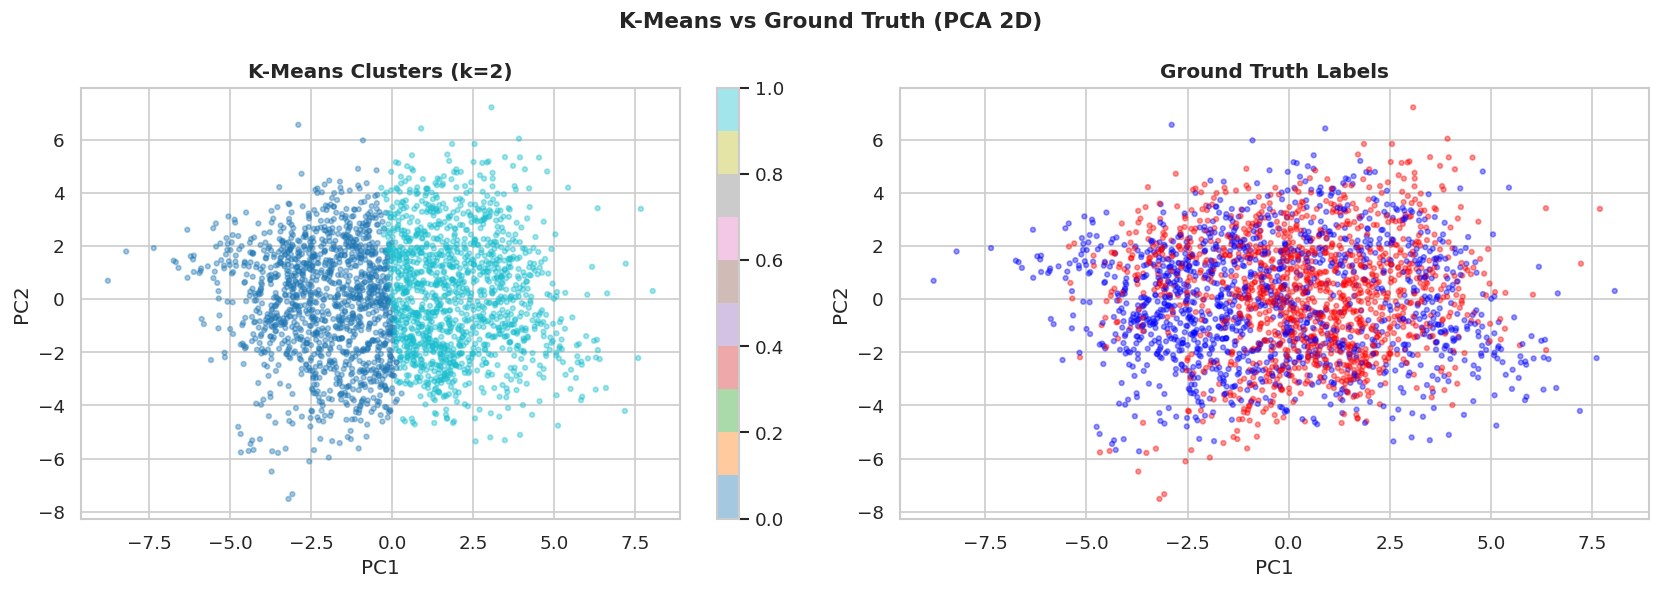

In [ ]:
# Visualise K-Means clusters in PCA 2D space
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter = axes[0].scatter(X_2d[:,0], X_2d[:,1], c=km_labels,
                          cmap='tab10', alpha=0.4, s=8)
axes[0].set_title(f'K-Means Clusters (k={best_k})', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[0])

axes[1].scatter(X_2d[:,0], X_2d[:,1], c=y_all.map({1:0,-1:1}),
                cmap='bwr', alpha=0.4, s=8)
axes[1].set_title('Ground Truth Labels', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.suptitle('K-Means vs Ground Truth (PCA 2D)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()